In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

***Fetching the Datasets***

In [2]:
train_dataset = pd.read_csv("data/train.csv")
test_dataset = pd.read_csv("data/test.csv")

# Drop the target and non-predictive columns for X
X_train = train_dataset.drop(['Survived', 'PassengerId', 'Name', 'Ticket'], axis=1)

# Only keep the target for y
y_train = train_dataset['Survived']

# Drop the target and non-predictive columns for X
X_test = test_dataset.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

# Preprocessing the Datasets

In [3]:
print(f"\n{X_train.info()}")
print(f"\n{X_test.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Cabin     204 non-null    object 
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(3), object(3)
memory usage: 55.8+ KB

None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    object 
 2   Age       332 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      417 non-null    float64
 6   Cabin     91 non

In [4]:
from sklearn.linear_model import LogisticRegression
from preprocessing_utils_pipeline_universal import get_preprocessing_pipeline

def add_titanic_features(df):
    df_copy = df.copy()
    if 'SibSp' in df_copy.columns and 'Parch' in df_copy.columns:
        df_copy['FamilySize'] = df_copy['SibSp'] + df_copy['Parch'] + 1
    # Add other Titanic-specific logic here...
    return df_copy

# Use it like this:
X_train_engineered = add_titanic_features(X_train)
pipeline = get_preprocessing_pipeline(X_train_engineered, LogisticRegression())
pipeline.fit(X_train_engineered, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Sex', 'Cabin', 'Embarked'], dtype='object'))])),
                ('model', LogisticRegression())])

Validation Accuracy: 82.12%


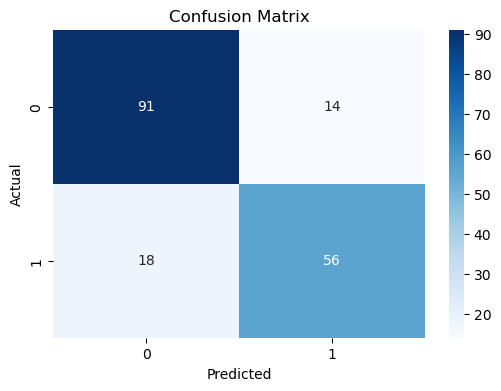

In [5]:
# Evaluating Logistic Regression model

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Split the engineered training data
# We use random_state=42 so the results are consistent every time you run it
X_val_train, X_val_test, y_val_train, y_val_test = train_test_split(
    X_train_engineered, y_train, test_size=0.2, random_state=42
)

# Re-fit the pipeline on ONLY the 80% training portion
pipeline.fit(X_val_train, y_val_train)

# Get predictions
y_pred = pipeline.predict(X_val_test)

# Calculate Accuracy
acc = accuracy_score(y_val_test, y_pred)
print(f"Validation Accuracy: {acc * 100:.2f}%")

cm = confusion_matrix(y_val_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [8]:
from sklearn.model_selection import cross_val_score

# 1. Run 5-fold cross validation
# This gives you 5 different accuracy scores
scores = cross_val_score(pipeline, X_train_engineered, y_train, cv=5)

"""
Run cross-validation on the preprocessing pipeline with engineered features
and print the fold scores plus summary statistics.
"""

# Run 5-fold cross validation on the full engineered training set.
# This returns one accuracy score for each fold.
scores = cross_val_score(pipeline, X_train_engineered, y_train, cv=5)

# Print the individual fold accuracy scores.
print(f"Scores: {scores}")

# Print the mean accuracy across all folds as an overall estimate.
print(f"Average Accuracy: {scores.mean() * 100:.2f}%")

# Print the standard deviation of the fold scores to show score variability.
print(f"Standard Deviation: {scores.std():.4f}")

Scores: [0.79888268 0.78651685 0.78651685 0.79213483 0.82022472]
Average Accuracy: 79.69%
Standard Deviation: 0.0125


In [9]:
from sklearn.model_selection import GridSearchCV

# 1. Define the "Grid" of parameters to test
# Note: 'model__' tells the pipeline to look inside the 'model' step
"""
Define the hyperparameter grid for the logistic regression model
inside the preprocessing pipeline, then run grid search to find
the best combination using cross-validation.
"""
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],  # regularization strength values to test
    'model__solver': ['liblinear', 'lbfgs'],  # solvers to compare for LogisticRegression
    'model__max_iter': [100, 200, 500]  # number of iterations to allow for convergence
}

# 2. Setup the Grid Search using the pipeline and the parameter grid
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# 3. Run the grid search on the engineered training data
grid_search.fit(X_train_engineered, y_train)

# 4. Print the best found hyperparameters and the corresponding CV score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_ * 100:.2f}%")

Best Parameters: {'model__C': 10, 'model__max_iter': 100, 'model__solver': 'liblinear'}
Best Cross-Validation Score: 79.91%
